# 1) Problem statement

###
    This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course

# 2) Data Collection

### 
    Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetld=74977 
    . The data consists of 8 column and 1000 rows.

# 2.1 Import data and required packages

### Importing pandas numpy matplotlib seaborn and warning libraries

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Importing CSV data as pandas Dataframe

In [82]:
df = pd.read_csv(r"C:\Users\sharief\Documents\projects\ML-Project\notebook\data\StudentsPerformance.csv")

In [83]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [84]:
df.shape

(1000, 8)

In [85]:
# there are 1000 rows and 8 columns

# 2.2 Dataset information:
    1.gender : male/female
    2.race/ethnicity : 'group A', 'group B', 'group C', 'group D', 'group E'
    3.parental level of education : "bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'
    4.lunch: 'standard', 'free/reduced']
    5.test preparation course : 'none', 'completed'
    6.math score : numeric column
    7.reading score : numeric column
    8.writing score : numeric column

    9. no null values in any column

# 3 Data Checks to perform
    1. check missing values
    2. check duplicates
    3. check data types
    4. check the number of unique values for each columns
    5. check statistics of the data
    6. check various categories in each categorical column

### 3.1 Check missing values

In [86]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

#### no missing values

### 3.2 Check duplicates

In [87]:
df.duplicated().sum()

np.int64(0)

#### no duplicate values

### 3.3 check data types

In [88]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

### 3.4 check the number of unique values for each column

In [89]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### 3.5 check statistics of data

In [90]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### 3.6 check various categories in each categorical column


In [91]:
cat_col = [i for i in df.columns if df[i].dtype == 'O']
for i in cat_col:
    print(f"{i}: {df[i].unique()}")

gender: ['female' 'male']
race/ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch: ['standard' 'free/reduced']
test preparation course: ['none' 'completed']


### 3.7 Adding total and average score as new columns

In [92]:
num_col = [i for i in df.columns if df[i].dtype!='O']
num_col

['math score', 'reading score', 'writing score']

In [93]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = df['total score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [101]:
reading_full = df[df['reading score'] == 100]['average score'].count()
print(f"Number of students with full reading score are {reading_full}\n")
math_full = df[df['math score'] == 100]['average score'].count()
print(f"Number of students with full math score are {math_full}\n")
writing_full = df[df['writing score'] == 100]['average score'].count()
print(f"Number of students with full writing score are {writing_full}")

Number of students with full reading score are 17

Number of students with full math score are 7

Number of students with full writing score are 14


In [106]:
reading_less_20 = df[df['reading score'] <= 20]['average score'].count()
print(f"Number of students with less than 20 in reading score are {reading_less_20}\n")
math_less_20 = df[df['math score'] <= 20]['average score'].count()
print(f"Number of students with less than 20 in math score are {math_less_20}\n")
writing_less_20 = df[df['writing score'] <= 20]['average score'].count()
print(f"Number of students with less than 20 in writing score are {writing_less_20}")

Number of students with less than 20 in reading score are 1

Number of students with less than 20 in math score are 4

Number of students with less than 20 in writing score are 3


### insights :
   #### from above scores, students in math have performed worst
   #### best performance is in reading score



### 4. Data Visualization

#### 4.1 Visualize average score to make some conclusions

    Histogram
    Kernal Distribution Function (KDE)

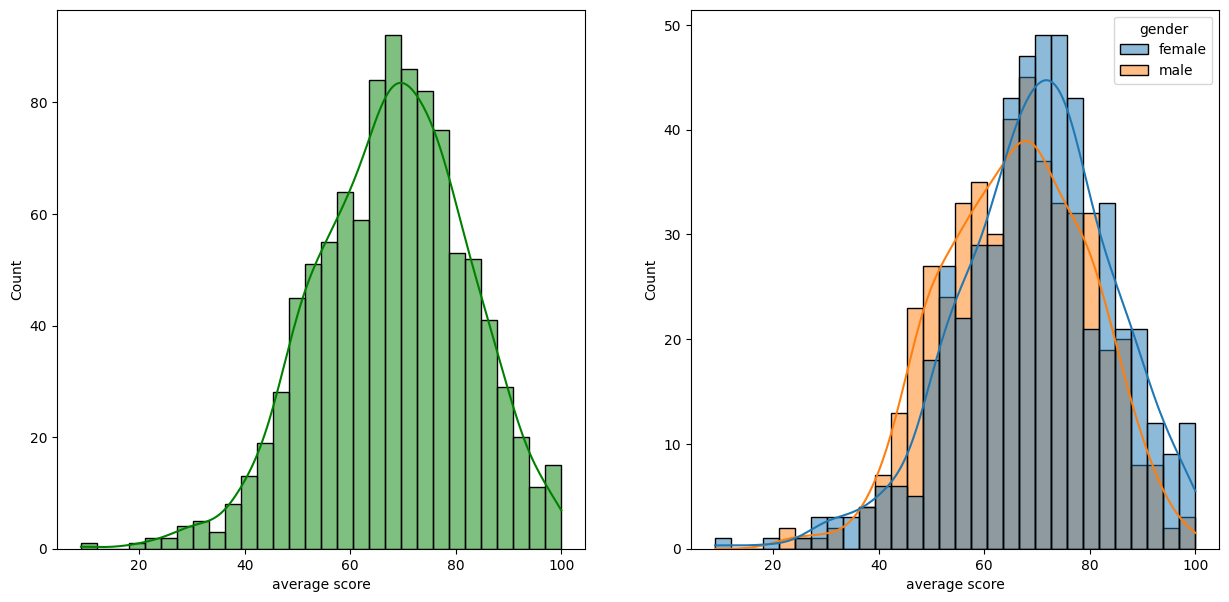

In [126]:
fig, axs =plt.subplots(1,2,figsize=(15,7))
#plt.subplots(121)
sns.histplot(data=df,x='average score',bins=30,kde=True,color='g',ax=axs[0])
#plt.subplot(122)
sns.histplot(data=df,x='average score',bins=30,kde=True,hue='gender',ax=axs[1])
plt.show()

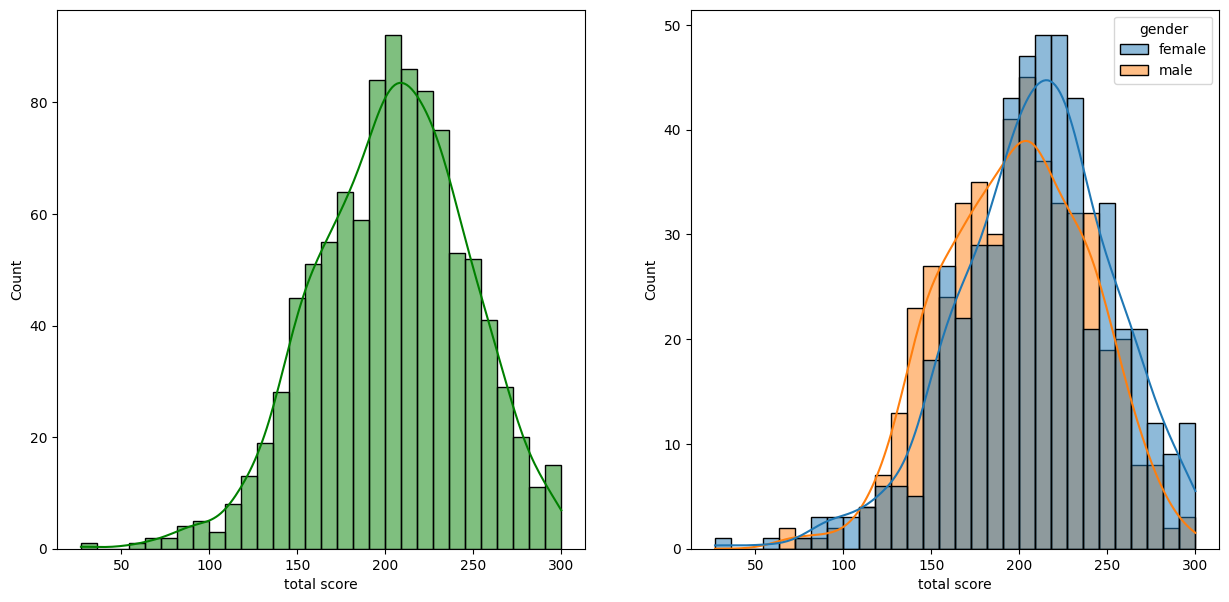

In [127]:
fig, axs =plt.subplots(1,2,figsize=(15,7))
#plt.subplots(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g',ax=axs[0])
#plt.subplot(122)
sns.histplot(data=df,x='total score',bins=30,kde=True,hue='gender',ax=axs[1])
plt.show()

#### Femals tend to perform better than male

<Axes: xlabel='average score', ylabel='Count'>

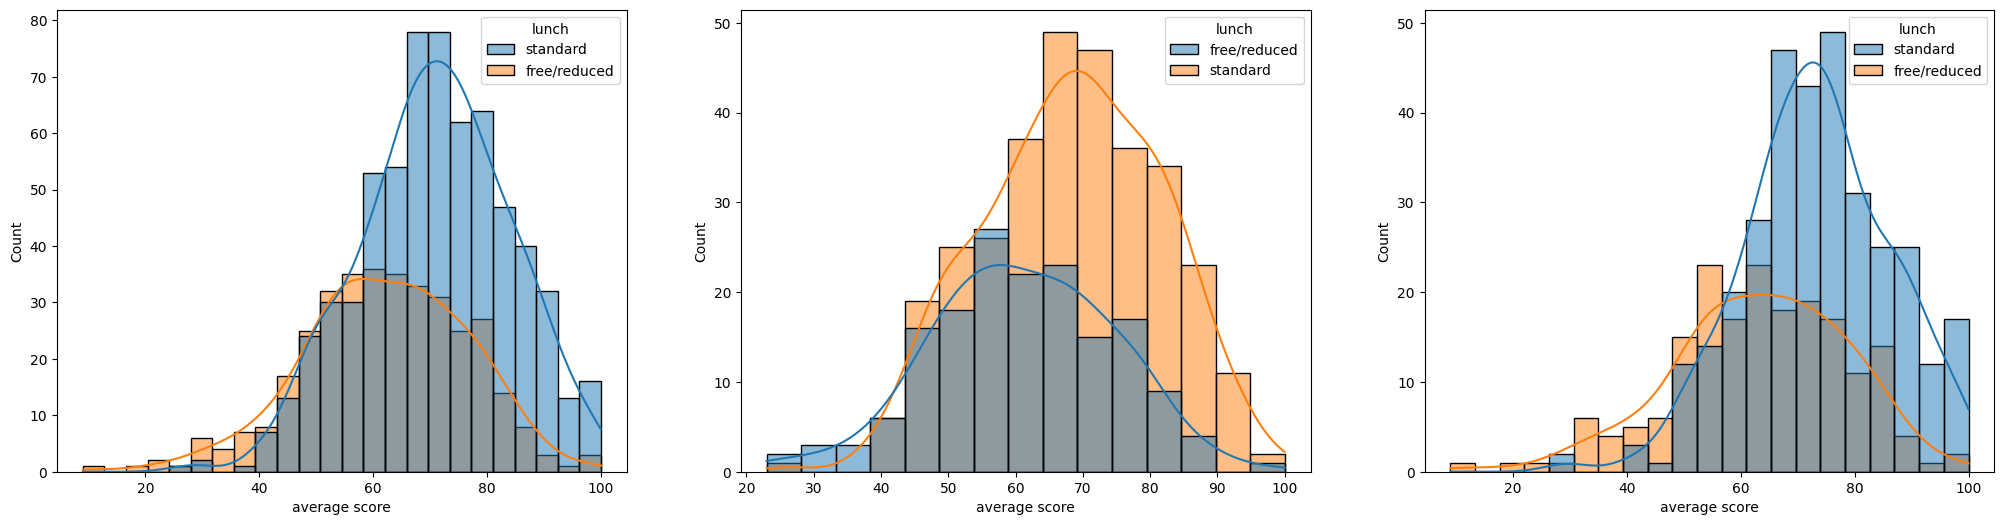

In [139]:
fig,axs = plt.subplots(1,3,figsize=(25,6))
sns.histplot(data=df,x='average score',hue='lunch',ax=axs[0],kde=True)
sns.histplot(x='average score',data=df[df.gender=='male'],kde=True,hue='lunch',ax=axs[1])
sns.histplot(data=df[df.gender == 'female'],x='average score',kde=True,  hue ='lunch',ax=axs[2])

#### performance of students are better when they are given standard lunch compare to free/reduced lunch

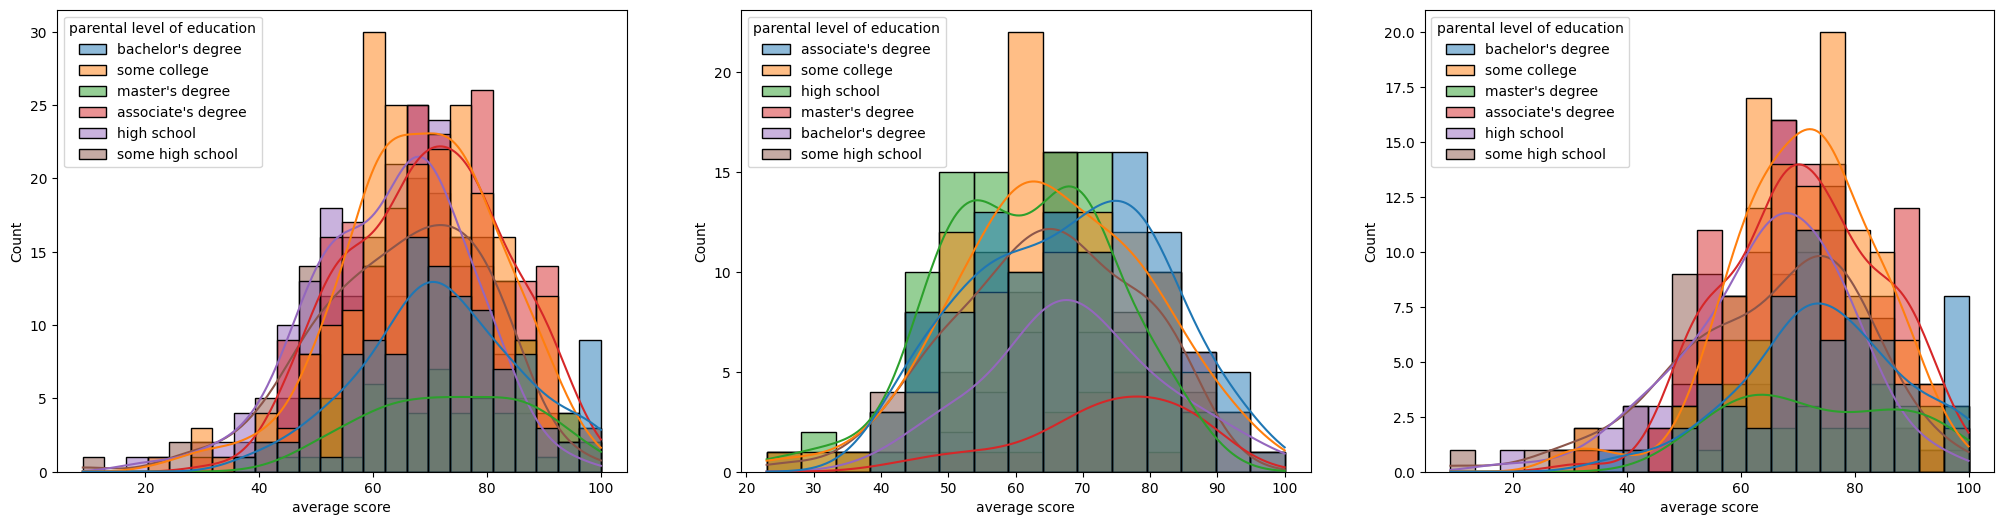

In [145]:
fig, axs=plt.subplots(1,3,figsize=(25,6))
sns.histplot(data=df,x='average score',hue='parental level of education',ax=axs[0],kde=True)
sns.histplot(data=df[df.gender=='male'],x='average score',hue='parental level of education', ax=axs[1],kde=True)
sns.histplot(data=df[df.gender=='female'],x='average score',hue='parental level of education', ax=axs[2],kde=True)
plt.show()

##### in genral parent's level of eduction has nothing to do with student's performance
##### in graph 2 it shows that male students whos partents are from "some college" have scored more compare to parents with master's and bachelor's degree
##### in graph 3 its the same trend....parents degree/ level of study does not impact students performance

In [147]:
df['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

<Axes: xlabel='average score', ylabel='Count'>

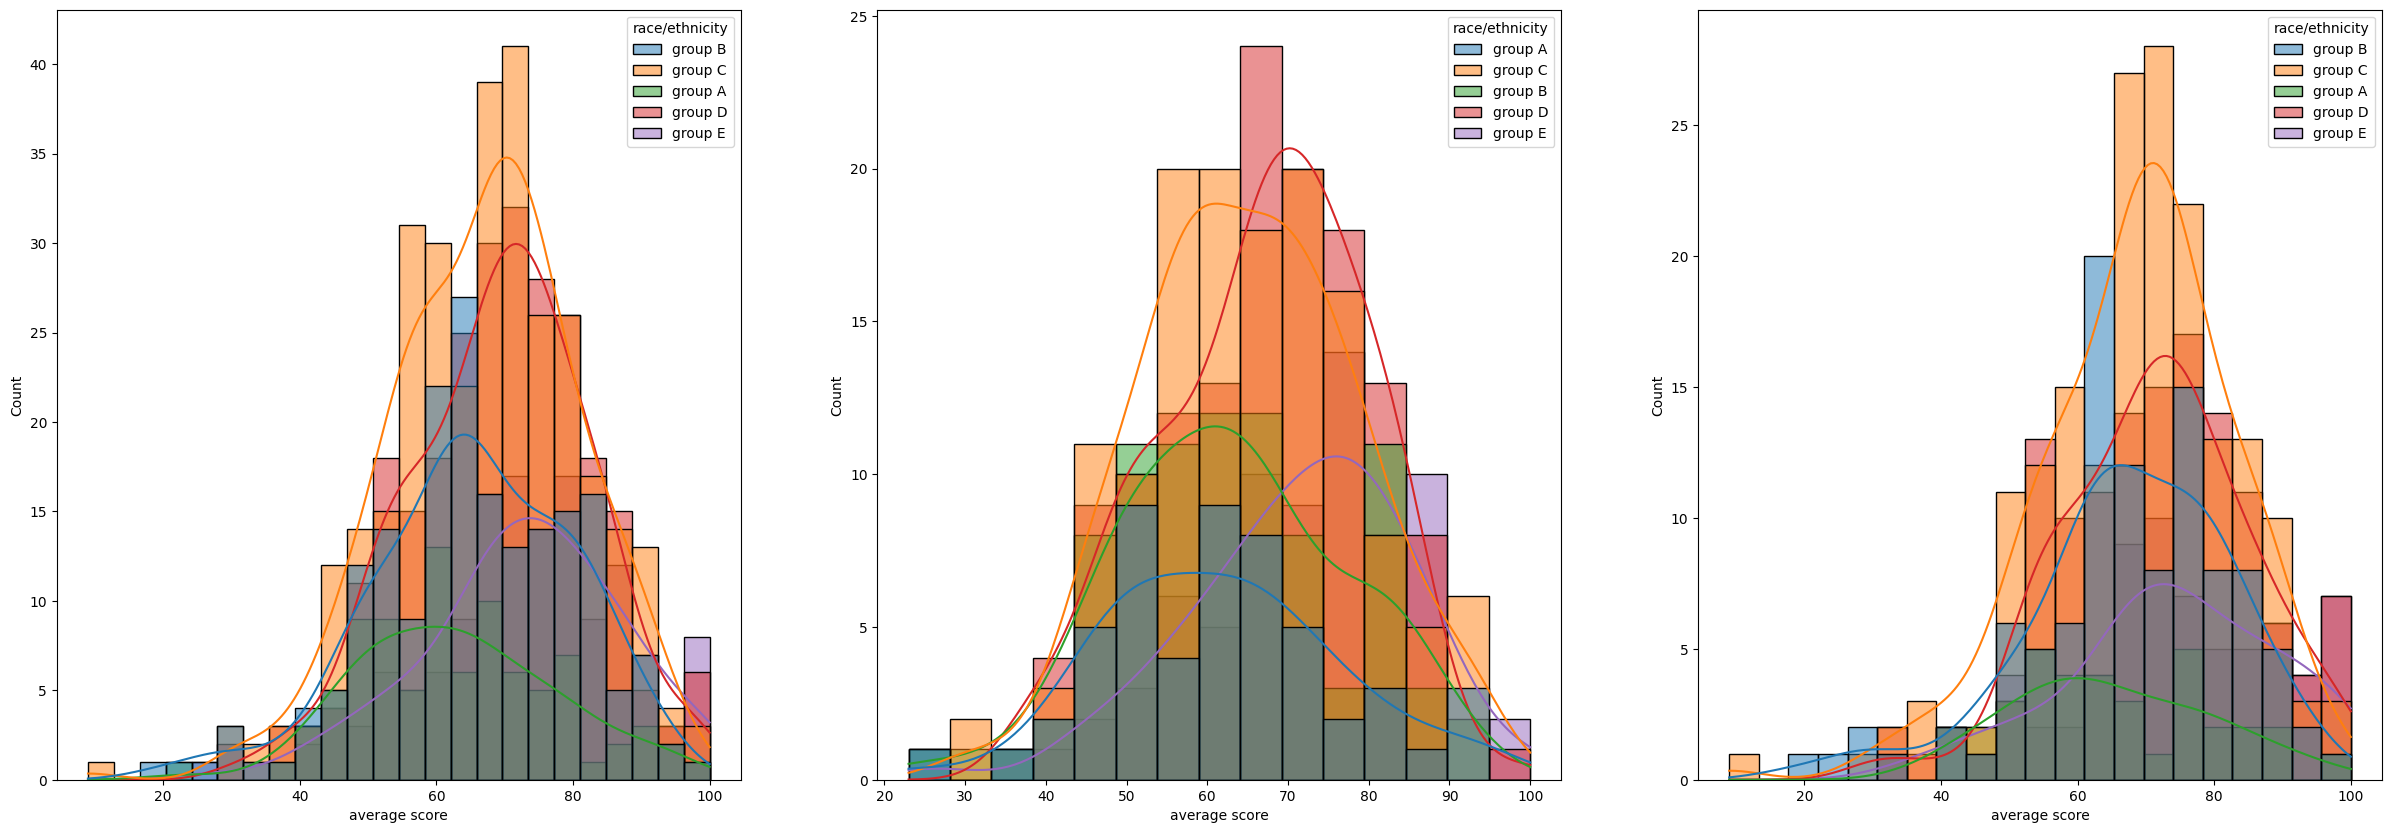

In [171]:
fig, axs = plt.subplots(1,3,figsize=(30,10))
sns.histplot(data=df,x='average score',kde=True,hue='race/ethnicity',ax=axs[0])
sns.histplot(data=df[df.gender=='male'],x='average score',kde=True,hue='race/ethnicity',ax=axs[1])
sns.histplot(data=df[df.gender=='female'],x='average score',kde=True,hue='race/ethnicity',ax=axs[2])

#### students of group A, B and E tend to perform poorly in exams irrespective to there genders

### 4.2 Maxium scores of students in each subject

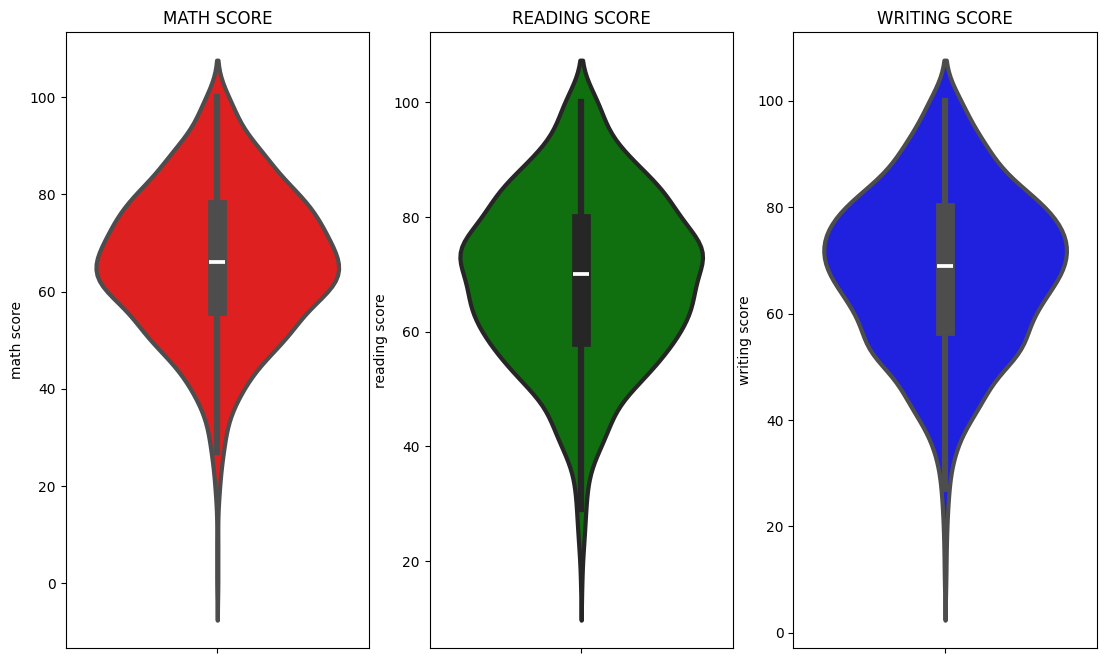

In [183]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('MATH SCORE')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(1,4,2)
plt.title('READING SCORE')
sns.violinplot(y='reading score',data=df,color='green',linewidth=3)
plt.subplot(1,4,3)
plt.title('WRITING SCORE')
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)
plt.show()

##### The violin plots show that most students score between 60–80 across all subjects.
##### Reading and writing have slightly higher medians compared to math, indicating better performance.
##### The density is more concentrated in reading and writing, suggesting more consistency, whereas math shows slightly more spread.

### 4.3 Multivariate analysis using pieplot

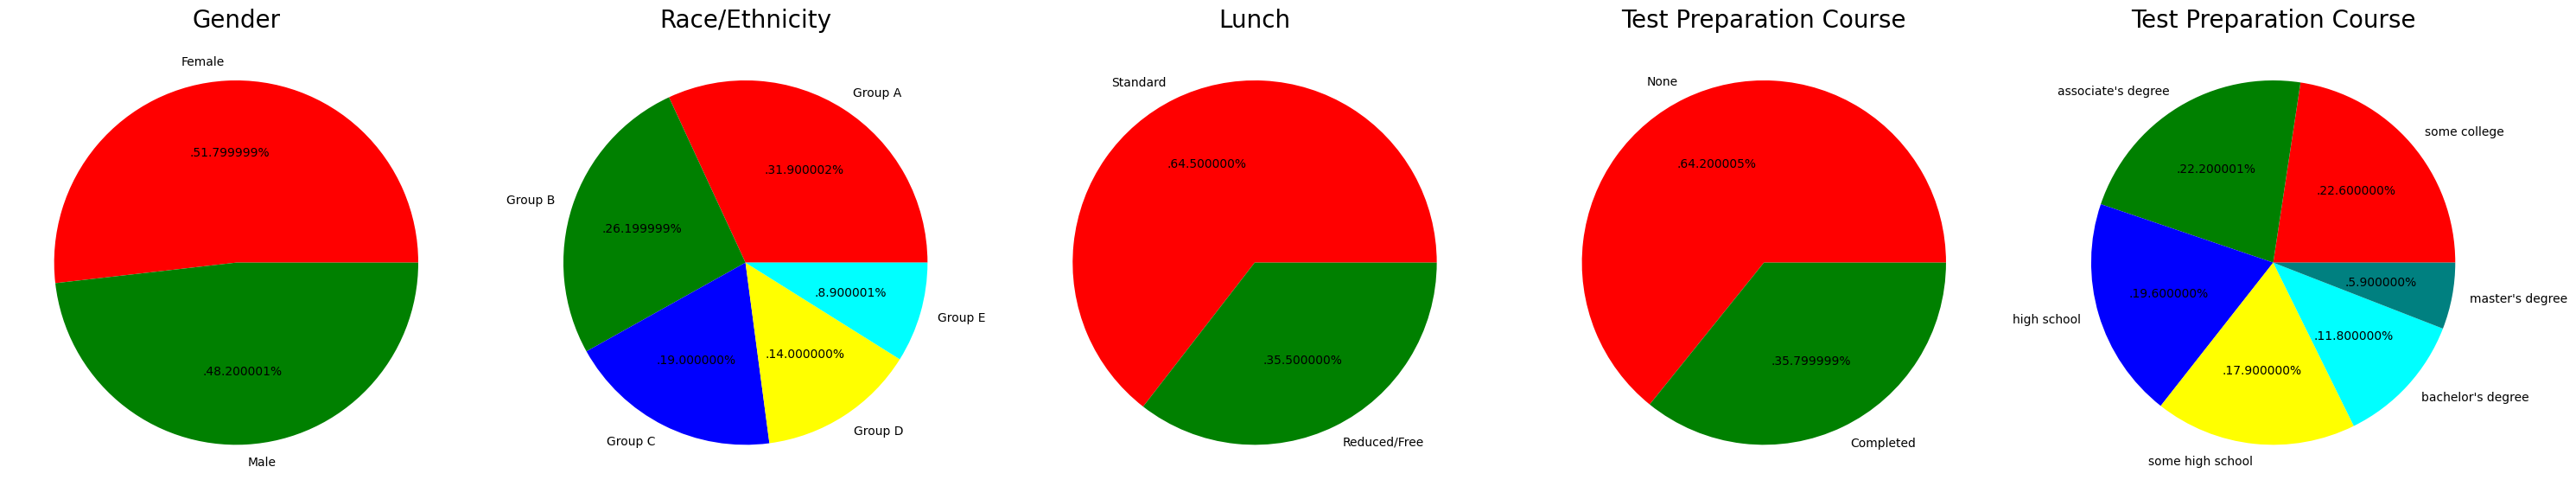

In [212]:
plt.rcParams['figure.figsize']=(30,12)

plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female','Male'
color = ['red','green']

plt.pie(size,labels=labels,colors=color,autopct='.%2f%%')
plt.title('Gender',fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size = df['race/ethnicity'].value_counts()
labels = 'Group A','Group B','Group C','Group D','Group E'
color = ['red','green','blue','yellow','cyan']

plt.pie(size,labels=labels,colors=color,autopct='.%2f%%')
plt.title('Race/Ethnicity',fontsize=20)
plt.axis('off')

plt.subplot(1,5,3)
size = df['lunch'].value_counts()
labels = 'Standard','Reduced/Free'
color = ['red','green']

plt.pie(size,labels=labels,colors=color,autopct='.%2f%%')
plt.title('Lunch',fontsize=20)
plt.axis('off')

plt.subplot(1,5,4)
size = df['test preparation course'].value_counts()
labels = 'None','Completed'
color = ['red','green']

plt.pie(size,labels=labels,colors=color,autopct='.%2f%%')
plt.title('Test Preparation Course',fontsize=20)
plt.axis('off')

plt.subplot(1,5,5)
size = df['parental level of education'].value_counts()
labels = 'some college',"associate's degree",'high school','some high school',"bachelor's degree","master's degree"
color = ['red','green','blue','yellow','cyan','teal']

plt.pie(size,labels=labels,colors=color,autopct='.%2f%%')
plt.title('Test Preparation Course',fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()

##### . Number of Male and Female students is almost equal
##### . Number students are greatest in Group C 
##### . Number of students who have standard lunch are greater 
##### · Number of students who have not enrolled in any test preparation course is greater 
##### . Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree" 

### 4.4 Feature Wise Visualization

### 4.4.1 Gender Column
    >how is the distribution of gender ?
    >does gender has any impact on scores?

#### Univariate Analysis 
    > how is the distribution of gender

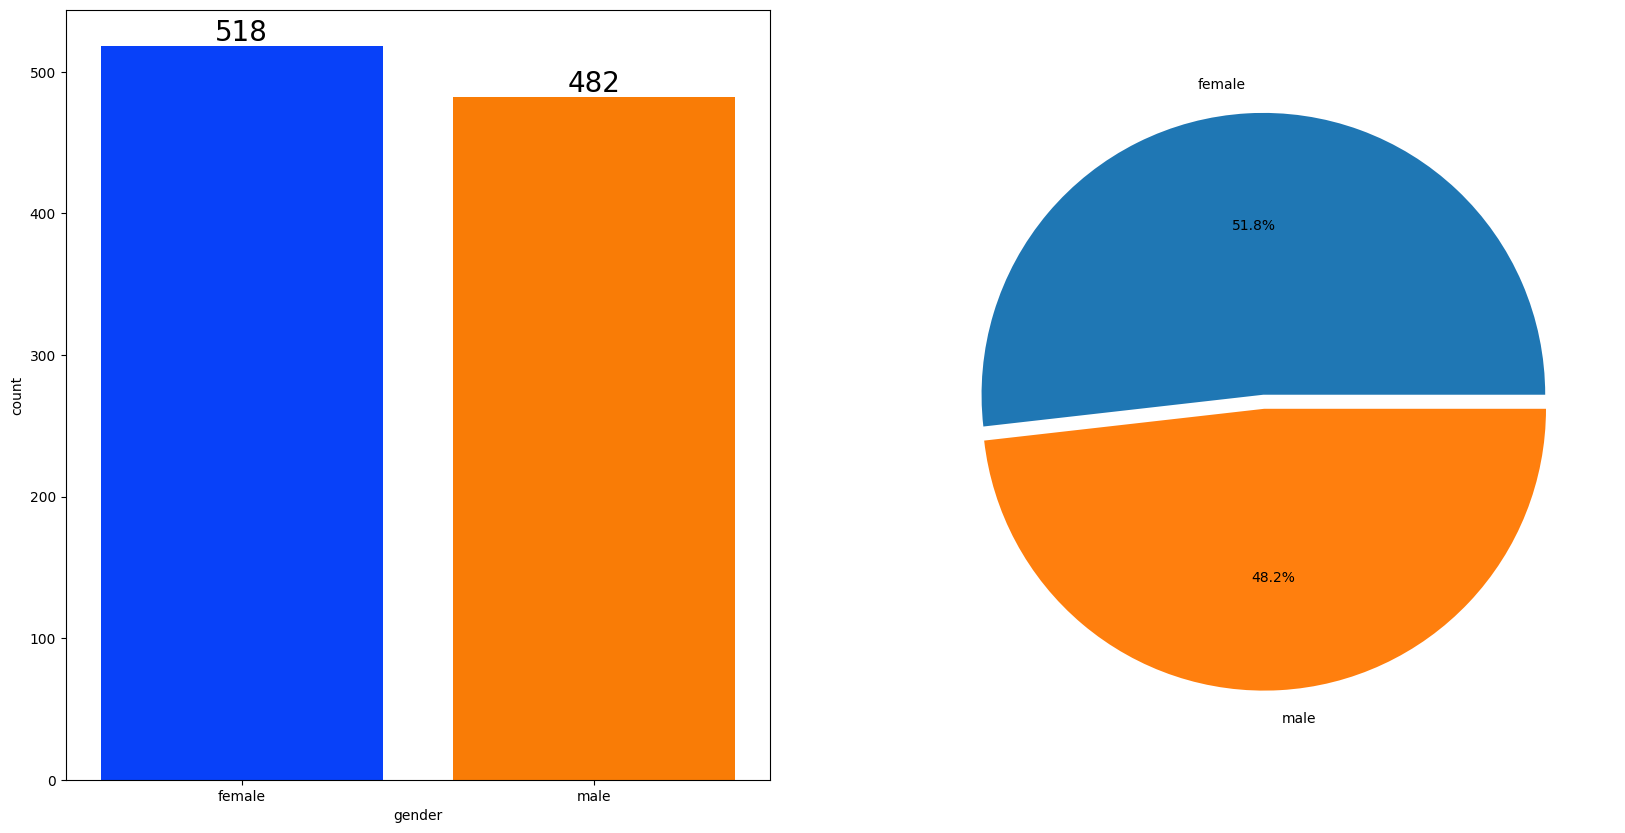

In [245]:
f, axs = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,ax=axs[0],palette='bright',saturation=0.95)
for i in axs[0].containers:
    axs[0].bar_label(i,color='black',size=20)

plt.pie(x=df['gender'].value_counts(),labels=df['gender'].unique(),explode=[0,0.05],autopct='%1.1f%%')
plt.show()

##### gender has balanced data with 482 male i.e 48.2% and 518 females i.e 51.8%

#### BIVARIATE ANALYSIS (does gender has any impact on student's performance)

In [252]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total score,average score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


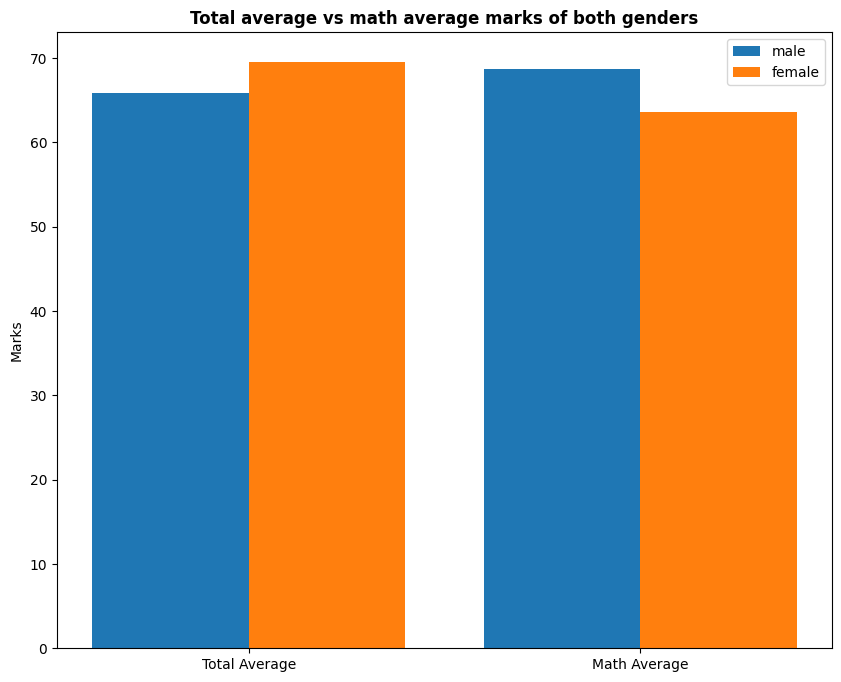

In [263]:
plt.figure(figsize=(10,8))

X = ['Total Average','Math Average']

female_score = [gender_group['average score'][0],gender_group['math score'][0]]
male_score = [gender_group['average score'][1],gender_group['math score'][1]]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2,male_score,0.4,label='male')
plt.bar(X_axis + 0.2,female_score,0.4,label='female')

plt.xticks(X_axis,X)
plt.ylabel("Marks")
plt.title("Total average vs math average marks of both genders",fontweight='bold')
plt.legend()
plt.show()

##### on average female have better overall score than male
##### but males have better average score in math

### 4.4.2 RACE / ETHNICITY COLUMN
##### how is group wise distribution?
##### does race/ethnicity have any impact on student's performance?

##### UNIVARIATE ANALYSIS

##### how is group wise distribution?

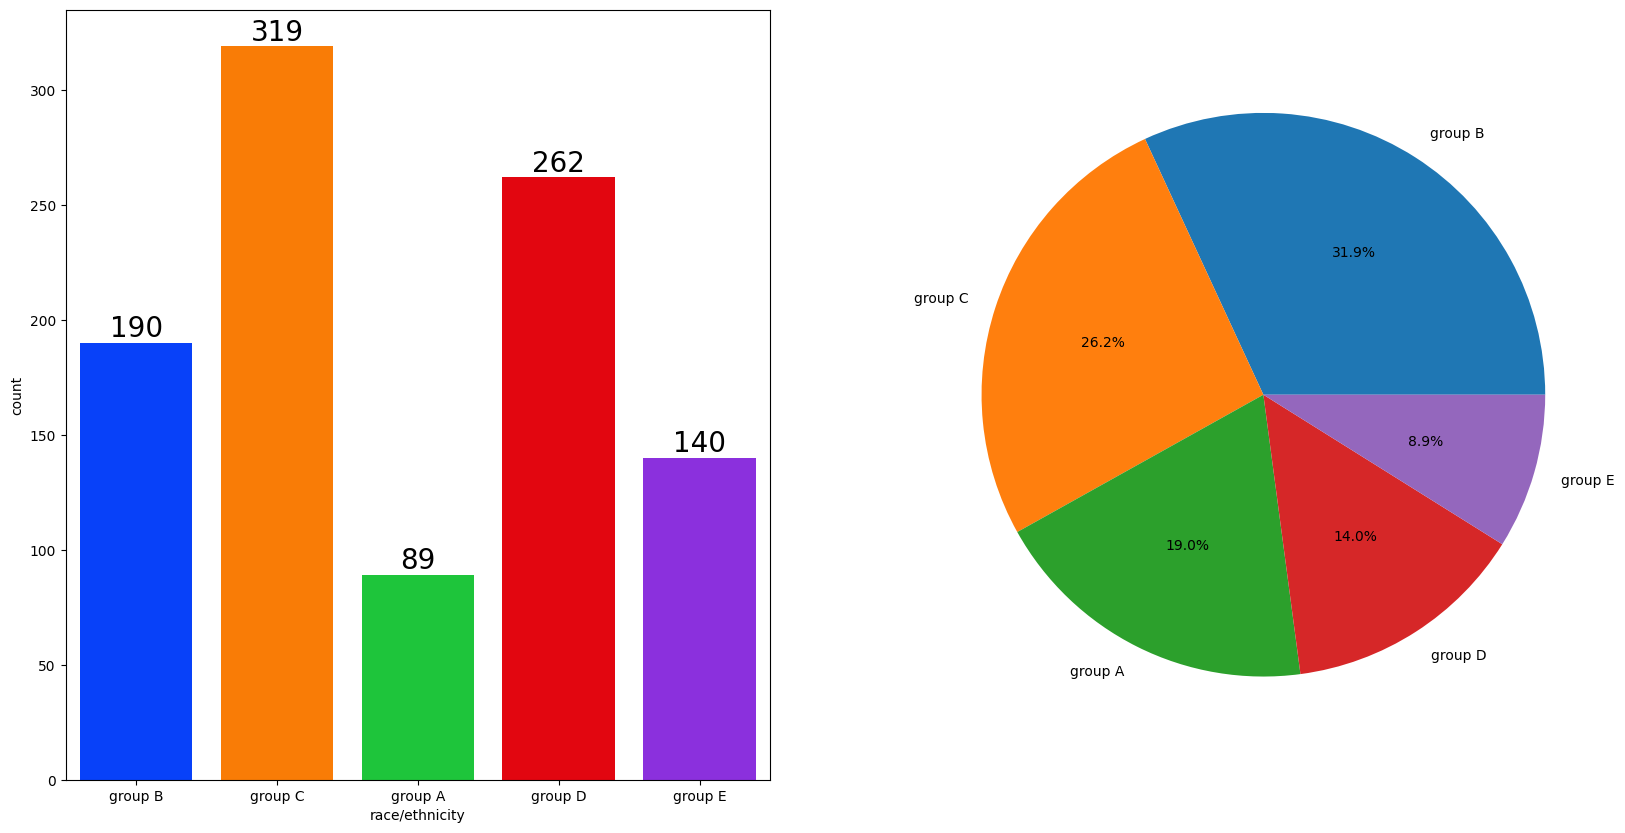

In [266]:
f, axs = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,ax=axs[0],palette='bright',saturation=0.95)
for i in axs[0].containers:
    axs[0].bar_label(i,color='black',size=20)

plt.pie(x=df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].unique(),autopct='%1.1f%%')
plt.show()

##### Group C and D have more number of students than group A B and E

#### bivariate Analysis
##### does race/ethnicity have any impaact on student's performance?

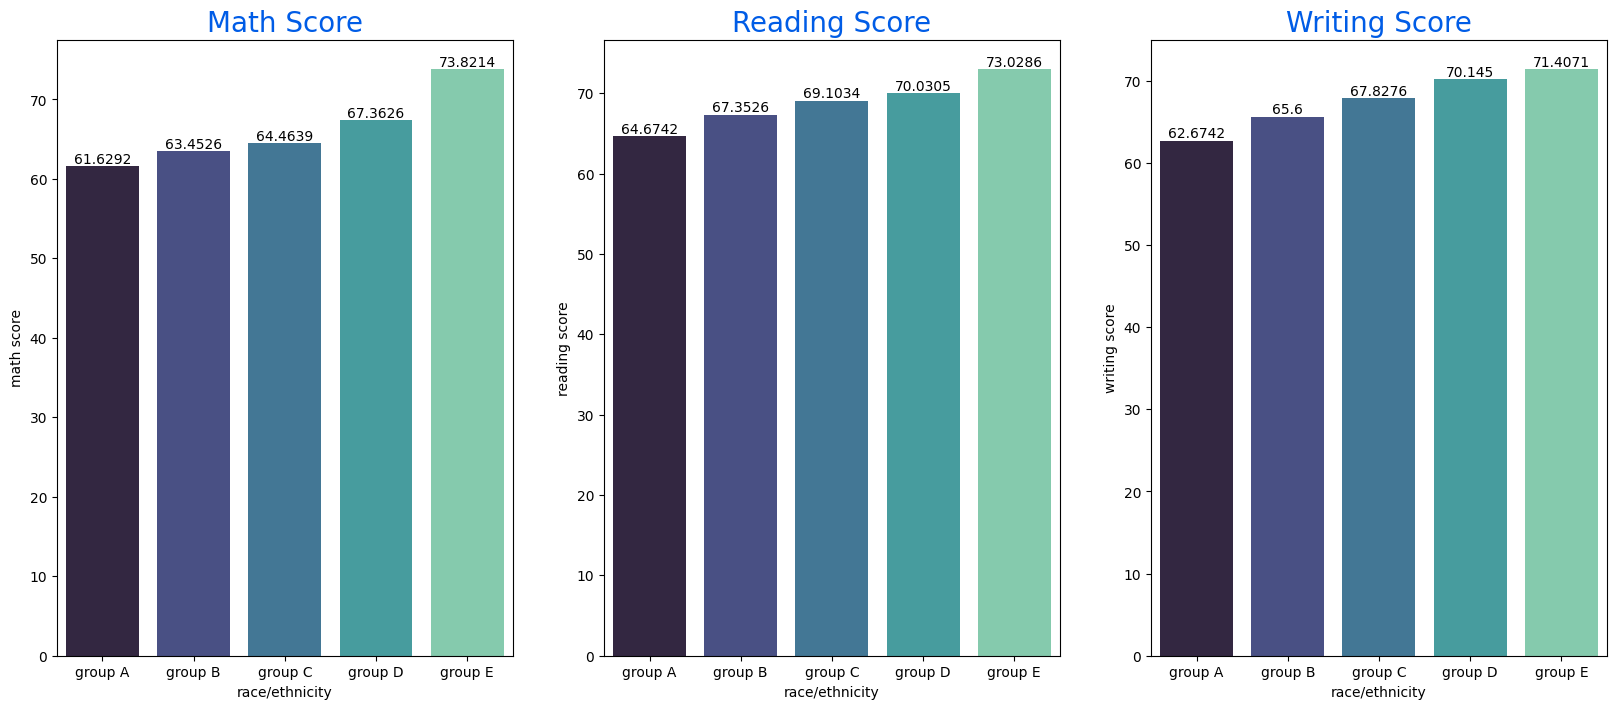

In [297]:
group = df.groupby('race/ethnicity').mean(numeric_only=True)
group

f, axs = plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=group.index,y=group['math score'],palette='mako',ax=axs[0])
axs[0].set_title("Math Score",color='#005ce6',size=20)

for i in axs[0].containers:
    axs[0].bar_label(i,size=10)

sns.barplot(x=group.index,y=group['reading score'],palette='mako',ax=axs[1])
axs[1].set_title('Reading Score',color="#005ce6",size=20)

for i in axs[1].containers:
    axs[1].bar_label(i,size=10)


sns.barplot(x=group.index,y=group['writing score'],palette='mako',ax=axs[2])
axs[2].set_title("Writing Score",color="#005ce6",size=20)

for i in axs[2].containers:
    axs[2].bar_label(i,size=10)

##### so overall group A, B , C are worst performers 
##### Group D and E are the best performers in every subject

### 4.4.3 parental eduction level Column
    >what is the parental eduction level ?
    >does parental eduction level  has any impact on scores?

## univariate analysis
##### what is the parental level education ?

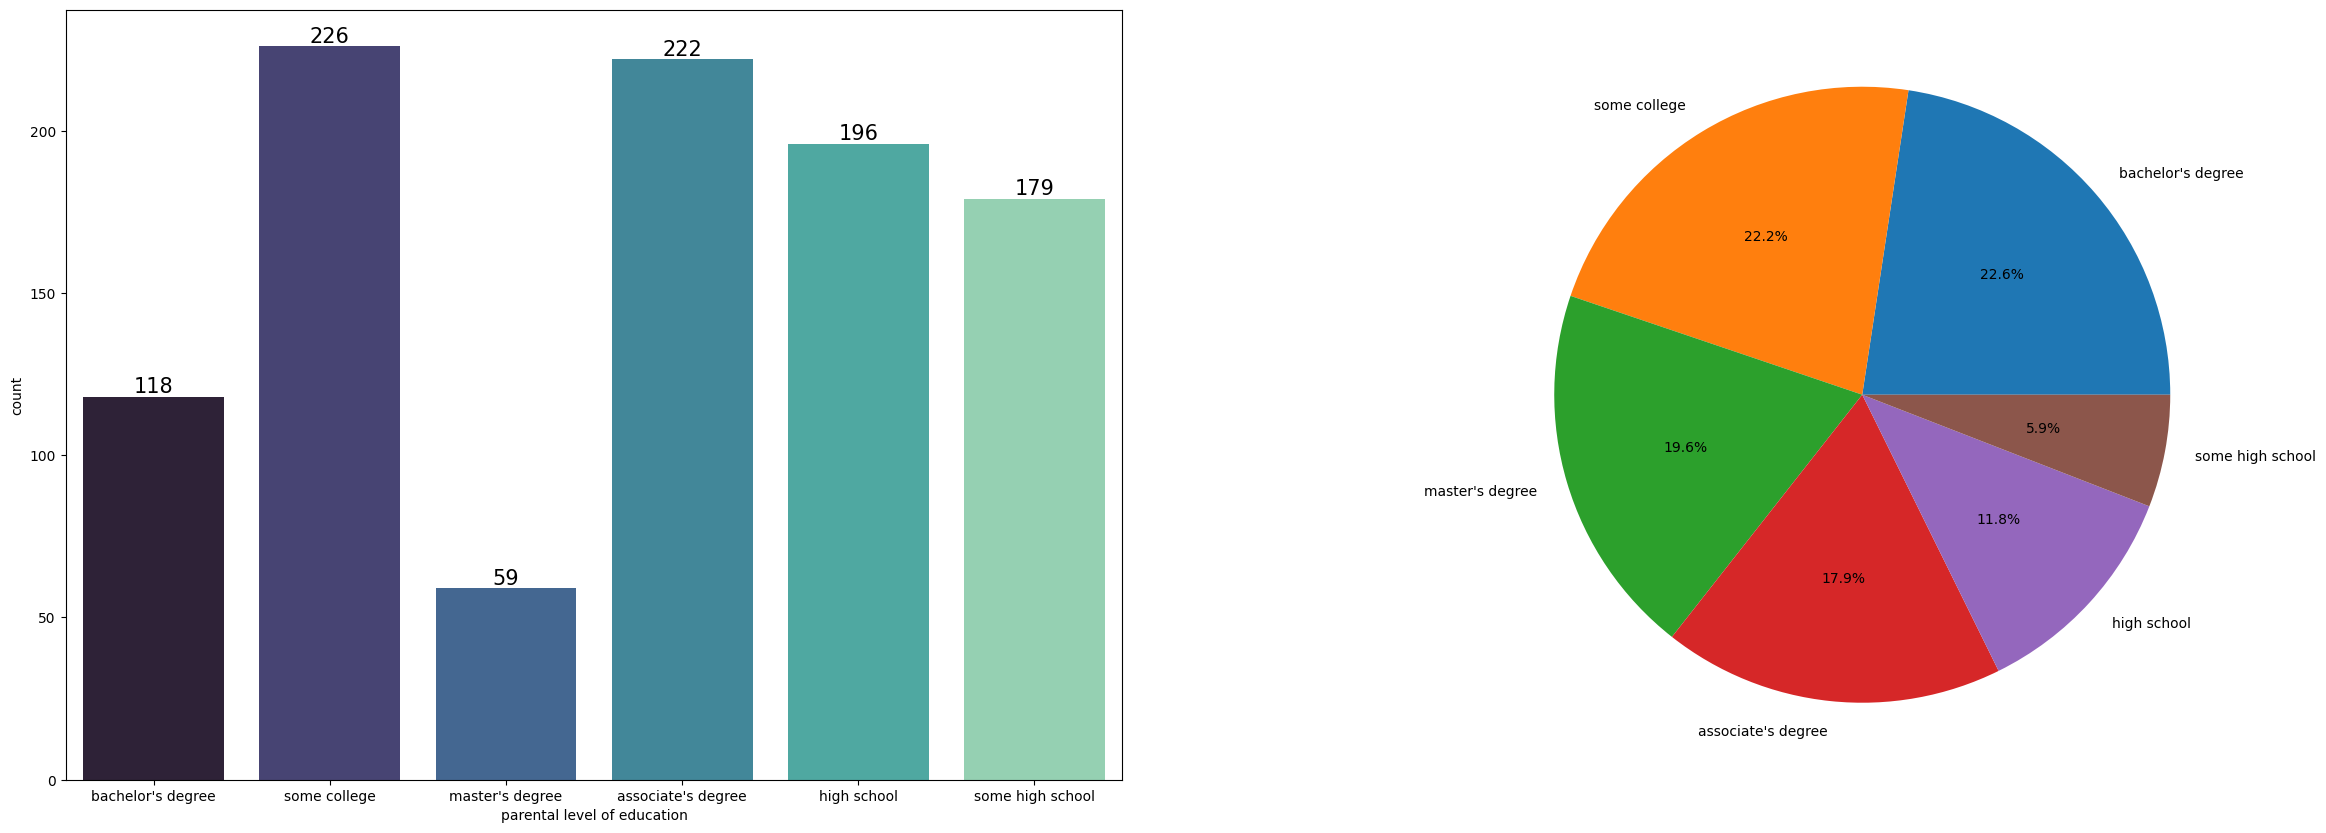

In [321]:
f, axs = plt.subplots(1,2,figsize=(30,10))

sns.countplot(x=df['parental level of education'],data=df,ax=axs[0],palette='mako')
for i in axs[0].containers:
    axs[0].bar_label(i,size=15)

plt.pie(x=df['parental level of education'].value_counts(),labels=df['parental level of education'].unique(),autopct='%1.1f%%')
plt.show()

##### parents from some college has more number of childern 
##### parents with  master's degree have least number of childern

## Bivarite Analysis
    >does parental eduction level  has any impact on scores?

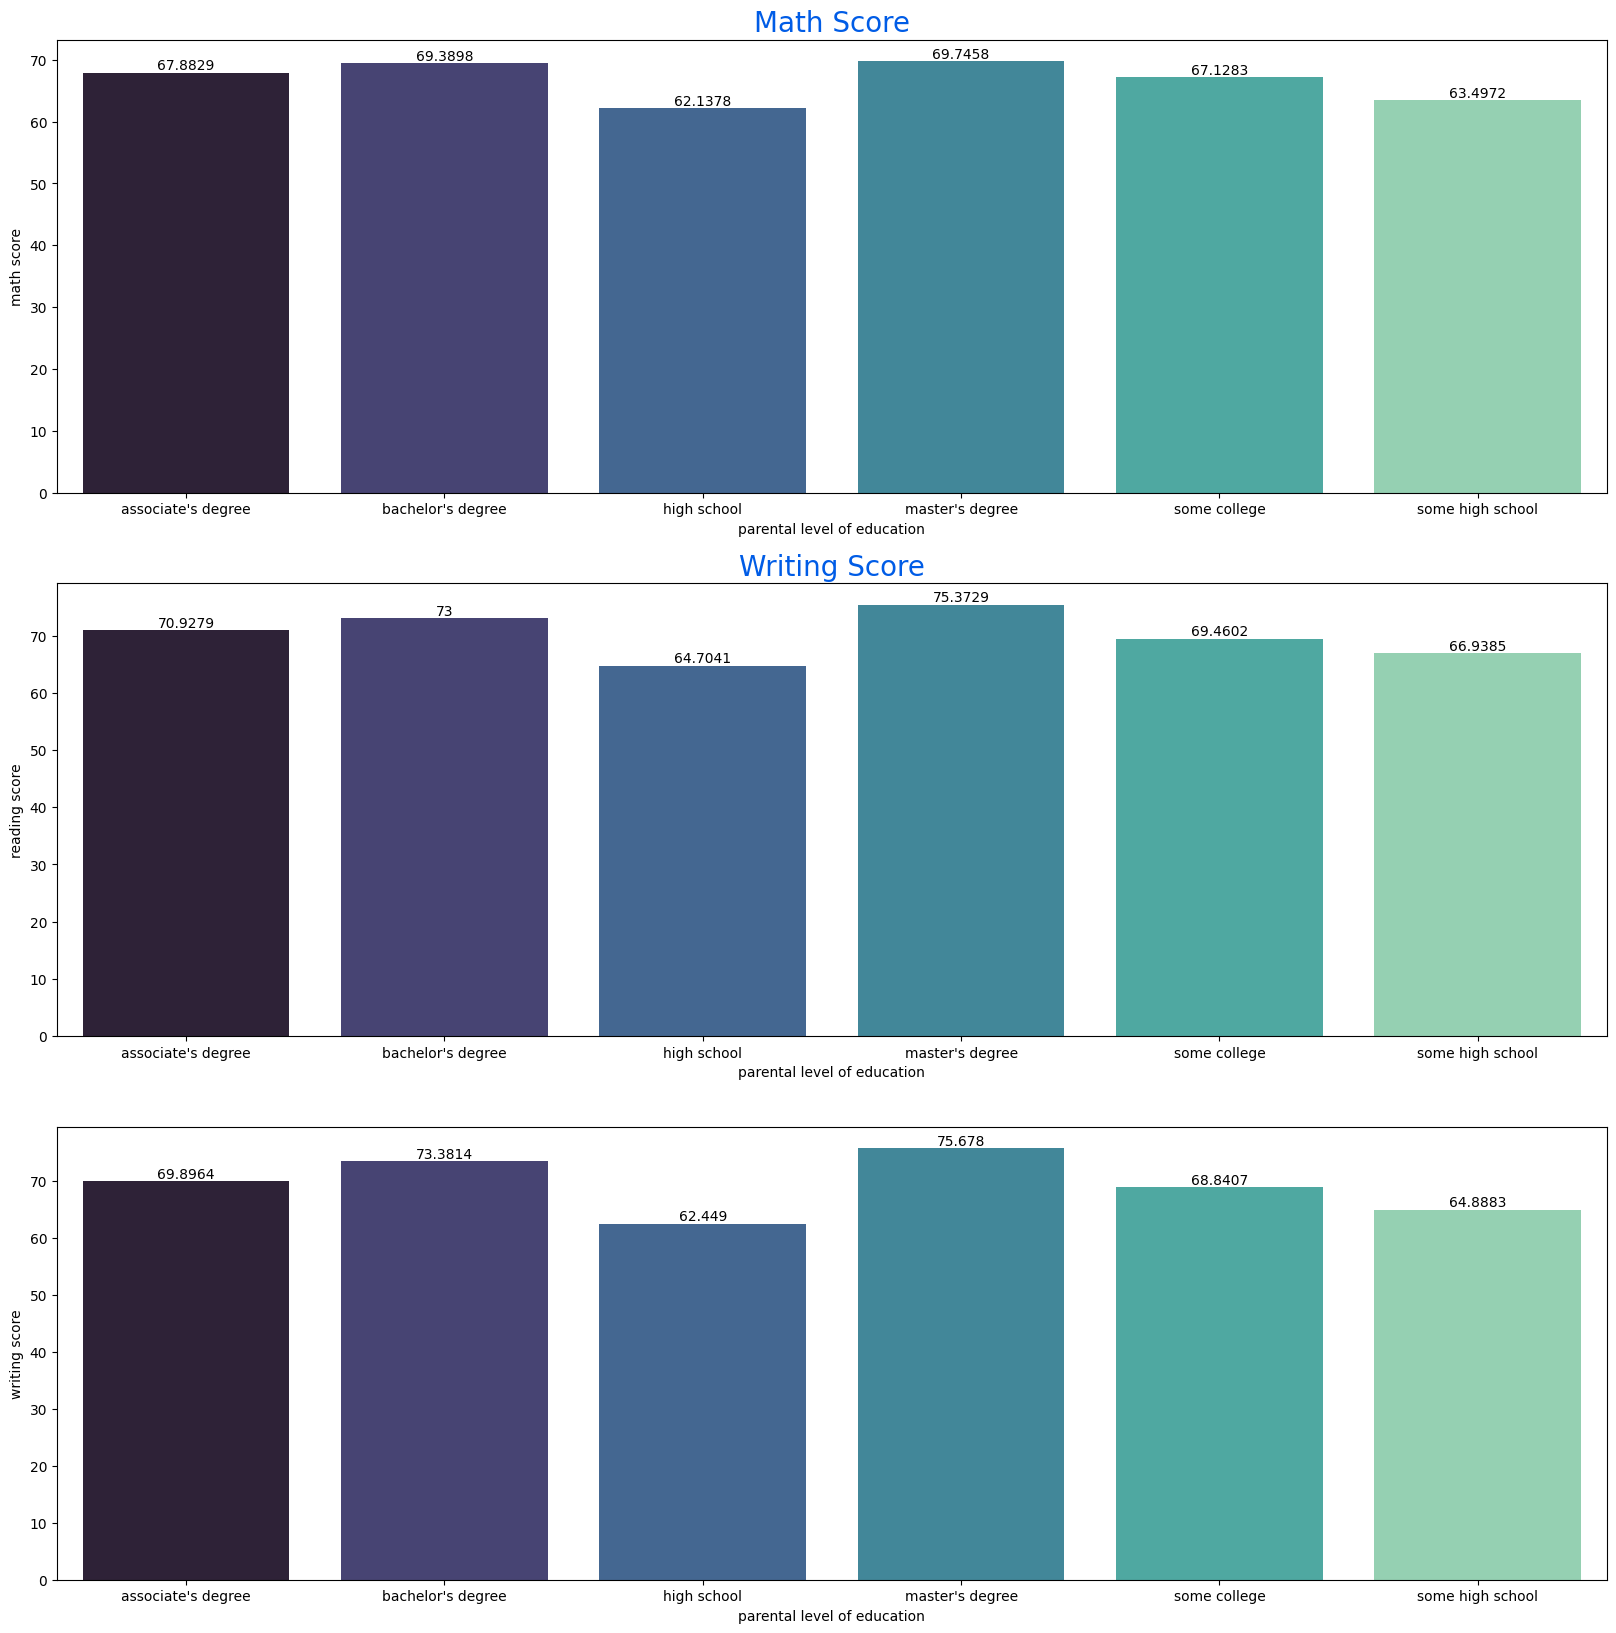

In [376]:
group1 = df.groupby('parental level of education').mean(numeric_only=True)
group1

f, axs = plt.subplots(3,1,figsize=(20,20))

sns.barplot(x=group1.index,y=group1['math score'],palette='mako',ax=axs[0])
axs[0].set_title("Math Score",color="#005ce6",size=20)
for i in axs[0].containers:
    axs[0].bar_label(i,size=10)

sns.barplot(x=group1.index,y=group1['reading score'], palette='mako',ax=axs[1])
axs[1].set_title("Reading Score",color="#005ce6",size=20)

for i in axs[1].containers:
    axs[1].bar_label(i,size=10)

sns.barplot(x=group1.index,y=group1['writing score'], palette='mako',ax=axs[2])
axs[1].set_title("Writing Score",color="#005ce6",size=20)

for i in axs[2].containers:
    axs[2].bar_label(i,size=10)

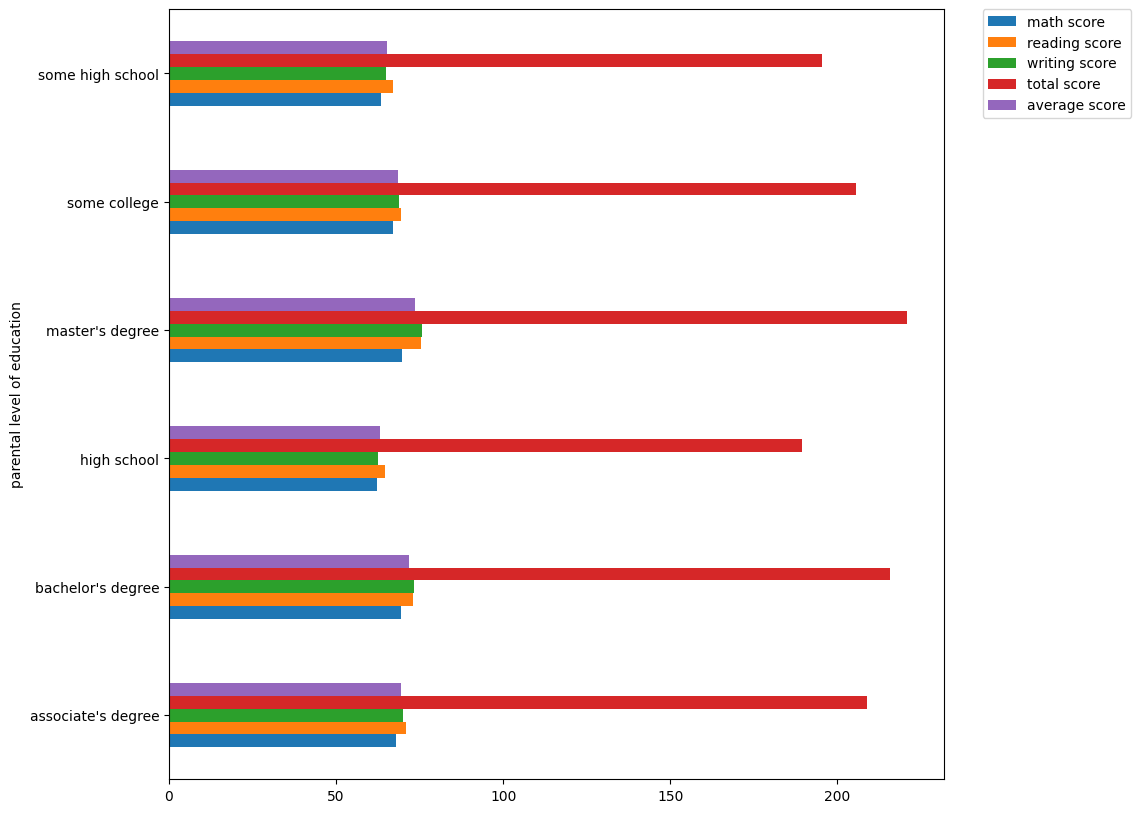

In [373]:
df.groupby('parental level of education').mean(numeric_only=True).plot(kind='barh',figsize=(10,10)) 
plt.legend(bbox_to_anchor=(1.05, 1),loc=2, borderaxespad=0.) 
plt.show()

##### on an avergae score of students of parents with master's degree is higher compare to other parents

##### Although students with highly educated parents show marginally higher average scores, the significant overlap in score distributions suggests that parental education is not a strong predictor of student performance.which is checked in KDE plot

In [353]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### 4.4.3 test preparation Column
    >what is the distribution of test preparation?
    >does test preparation  has any impact on scores?

## univariate analysis
##### what is the distribution of test preparation?

([<matplotlib.patches.Wedge at 0x26583aa5950>,
 [Text(-0.4746018502673304, 0.9923472596439347, 'none'),
  Text(0.47460146383300333, -0.9923474444606439, 'completed')],
 [Text(-0.25887373650945295, 0.5412803234421462, '64.2%'),
  Text(0.2588735257270927, -0.5412804242512602, '35.8%')])

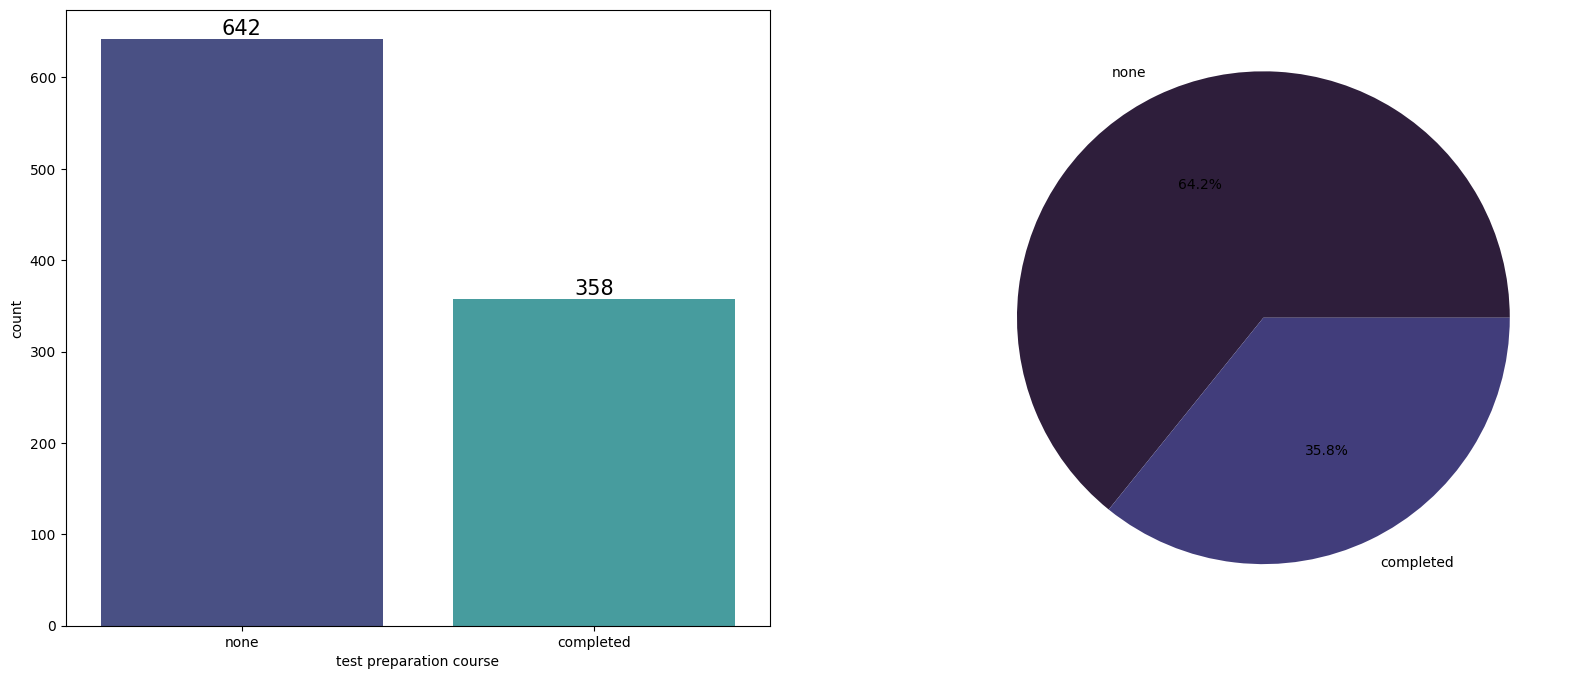

In [379]:
f, axs = plt.subplots(1,2,figsize=(20,8))

sns.countplot(data=df,x=df['test preparation course'],ax=axs[0],palette='mako')
for i in axs[0].containers:
    axs[0].bar_label(i,size=15)

plt.pie(x=df['test preparation course'].value_counts(),labels=df['test preparation course'].unique(),colors=sns.color_palette('mako'),autopct='%1.1f%%')

##### There are more number of students who did not take test preparation course i.e 642 students
##### only 358 students took test preparation course

## BIVARIATE ANALYSIS

In [385]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [388]:
group2 = df.groupby('test preparation course').mean(numeric_only=True)
group2

,math score,reading score,writing score,total score,average score
test preparation course,,,,,
completed,69.695531,73.893855,74.418994,218.008380,72.669460
none,64.077882,66.534268,64.504673,195.116822,65.038941


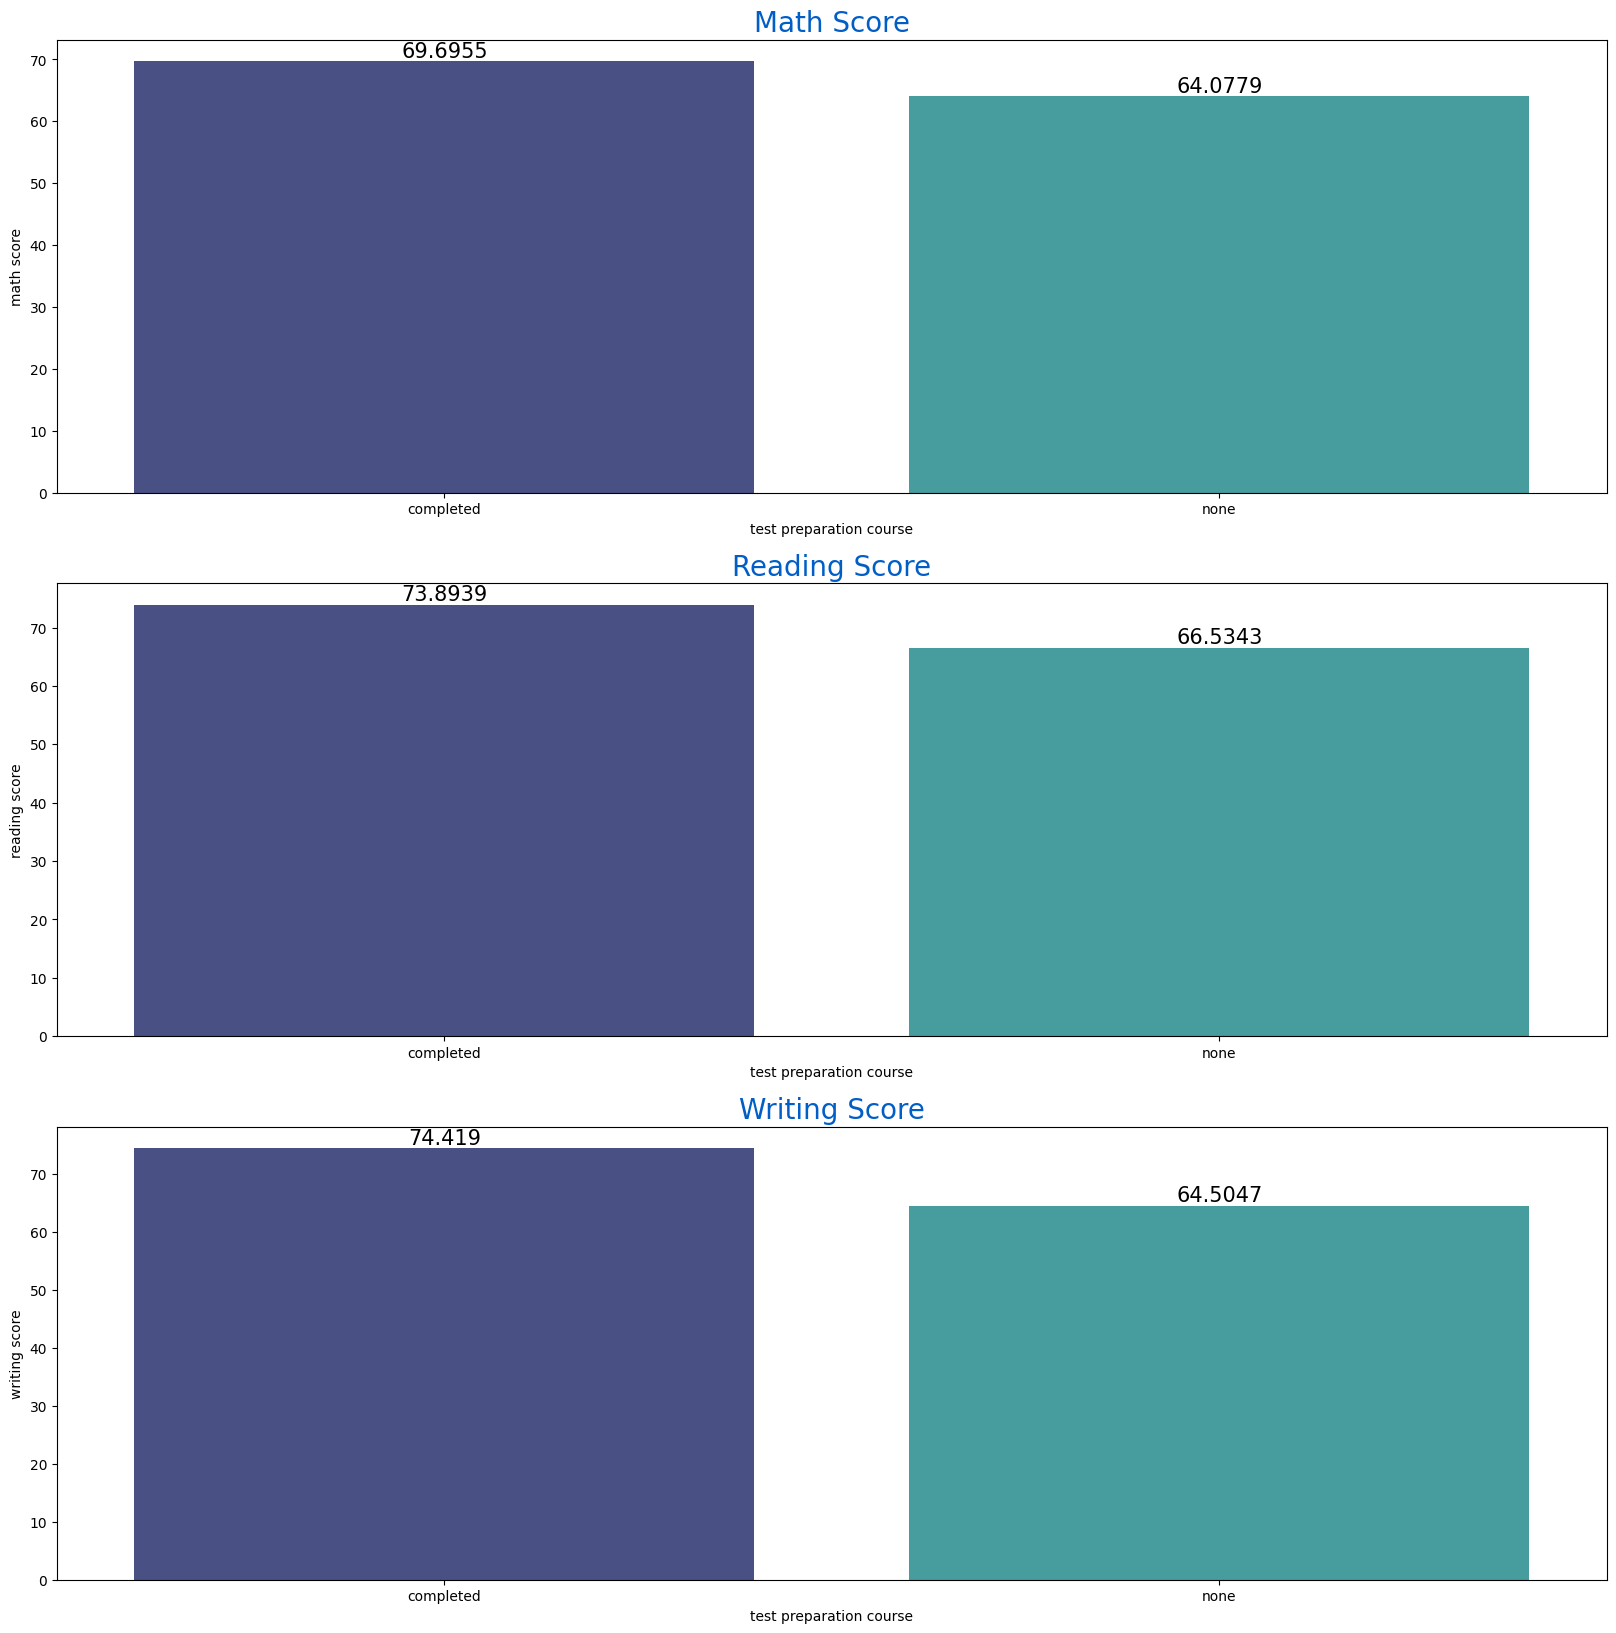

In [411]:
f, axs = plt.subplots(3,1,figsize=(20,20))

sns.barplot(x=group2.index,y=group2['math score'],ax=axs[0],palette = 'mako')
axs[0].set_title("Math Score",color="#005ec6",size=20)

for i in axs[0].containers:
    axs[0].bar_label(i,size=15)

sns.barplot(x=group2.index,y=group2['reading score'],ax=axs[1],palette = 'mako')
axs[1].set_title("Reading Score",color="#005ec6",size=20)

for i in axs[1].containers:
    axs[1].bar_label(i,size=15)

sns.barplot(x=group2.index,y=group2['writing score'],ax=axs[2],palette = 'mako')
axs[2].set_title("Writing Score",color="#005ec6",size=20)

for i in axs[2].containers:
    axs[2].bar_label(i,size=15)

plt.show()

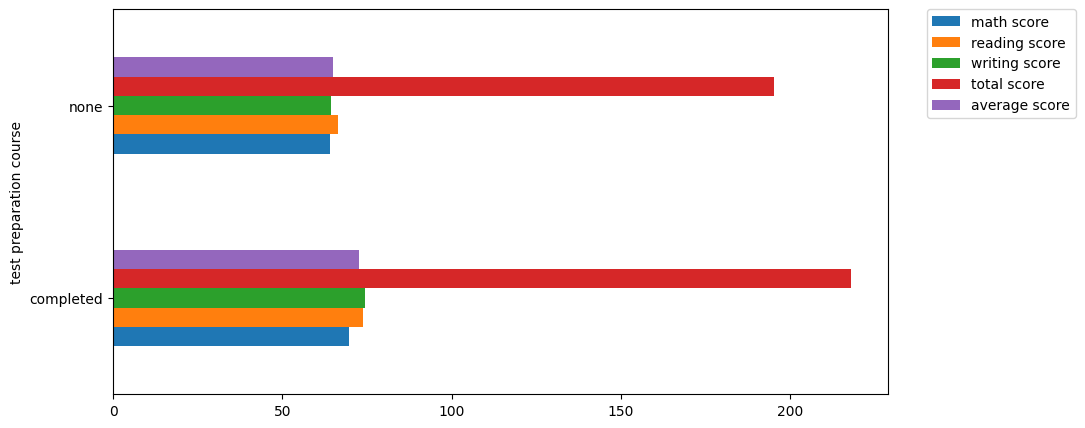

In [422]:
df.groupby('test preparation course').mean(numeric_only=True).plot(kind='barh',figsize=(10,5))
plt.legend(bbox_to_anchor=(1.05, 1),loc=2, borderaxespad=0.)
plt.show()

##### student's who have taken test preparation course have scored more than the students who didn't complete test perparation course

### checking if students of parents with no strong education have not enrolled/compeleted test preparation course

In [454]:
percent_table = round(pd.crosstab(df['parental level of education'],df['test preparation course'],normalize='index')*100,2)
percent_table

test preparation course,completed,none
parental level of education,,
associate's degree,36.94,63.06
bachelor's degree,38.98,61.02
high school,28.57,71.43
master's degree,33.90,66.10
some college,34.07,65.93
some high school,43.02,56.98


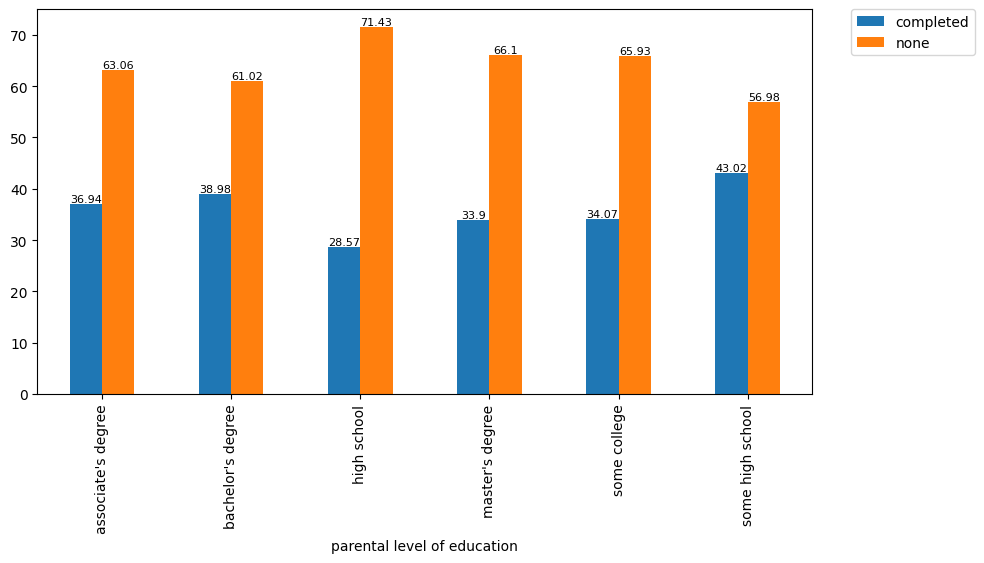

In [458]:
ax = percent_table.plot(kind='bar',figsize=(10,5))
plt.legend(bbox_to_anchor=(1.05, 1),loc=2, borderaxespad=0.)
for i in ax.containers:
    ax.bar_label(i,size=8)

###### So, parents with high school degree have more children not enrolled 71.43% compare to other degree

## 4.4.4 Check for outliers

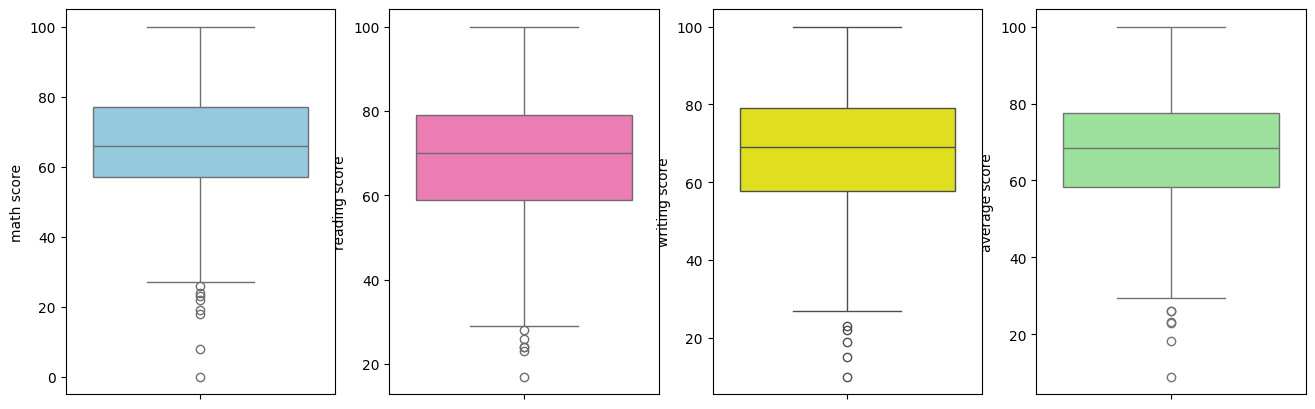

In [466]:
f,axs =plt.subplots(1,4,figsize=(16,5))
sns.boxplot(df['math score'],ax=axs[0],color='skyblue')
sns.boxplot(df['reading score'],ax=axs[1],color='hotpink')
sns.boxplot(df['writing score'],ax=axs[2],color='yellow')
sns.boxplot(df['average score'],ax=axs[3],color='lightgreen')
plt.show()

##### such outliers , just real data with students scoring less marks

## 4.4.5 Multivariate Analysis using pair plot

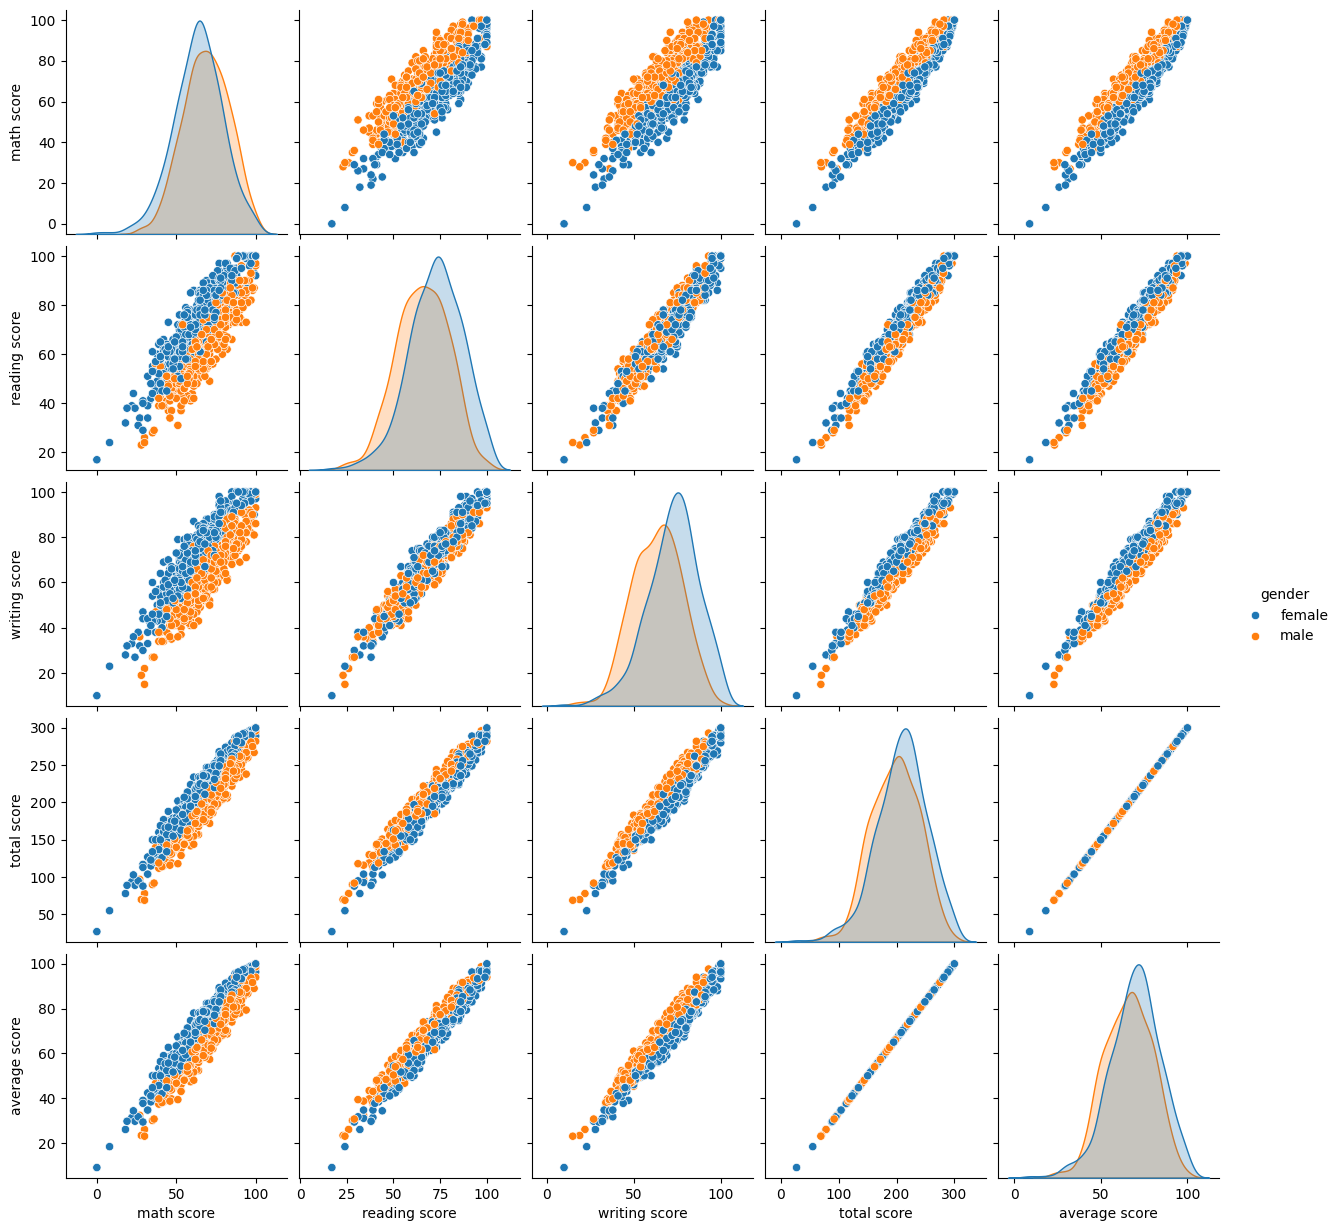

In [469]:
sns.pairplot(df,hue='gender')

##### The pairplot shows strong positive correlations among all score variables, with reading and writing being highly correlated. Gender-wise, female students tend to perform slightly better in reading and writing, while math scores show more variation among males. Additionally, total and average scores are derived features and exhibit perfect linear relationships.

## Conclusion:
### . Student's Performance is related with lunch, race, parental level education 
### . Females lead in pass percentage and also are top-scorers 
### . Student's Performance is not much related with test preparation course 
### · Finishing preparation course is benefitial.